## Load the important libraries

In [104]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score
)


### Load the dataset

In [105]:
# Reading the data from .csv file
df = pd.read_csv("Lab_Exam_binary_classification_dataset.csv")

In [106]:
# display the first 3 rows
df.head(3)

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes


## Load & Clean Data

In [107]:
df = pd.read_csv("Lab_Exam_binary_classification_dataset.csv")
df = df.dropna()                          # remove 20 missing Target rows
df = df[df["Feature1"] < 100]            # remove 1 outlier (Feature1=10000)
df = df.reset_index(drop=True)

In [108]:
print("Shape:", df.shape)
print(df.head())
print("\nClass counts:\n", df["Target"].value_counts())
print("\nDescriptive Stats:\n", df.describe())

Shape: (999, 3)
   Feature1  Feature2 Target
0    1.7250       520    Yes
1    1.8875       428     No
2    1.6000       552    Yes
3    1.4250       500     No
4    1.7750       628     No

Class counts:
 Target
No     784
Yes    215
Name: count, dtype: int64

Descriptive Stats:
          Feature1    Feature2
count  999.000000  999.000000
mean     1.634547  521.109109
std      0.220714   70.005347
min      1.250000  400.000000
25%      1.450000  464.000000
50%      1.637500  520.000000
75%      1.831250  584.000000
max      2.000000  640.000000


## TASK 1: EDA

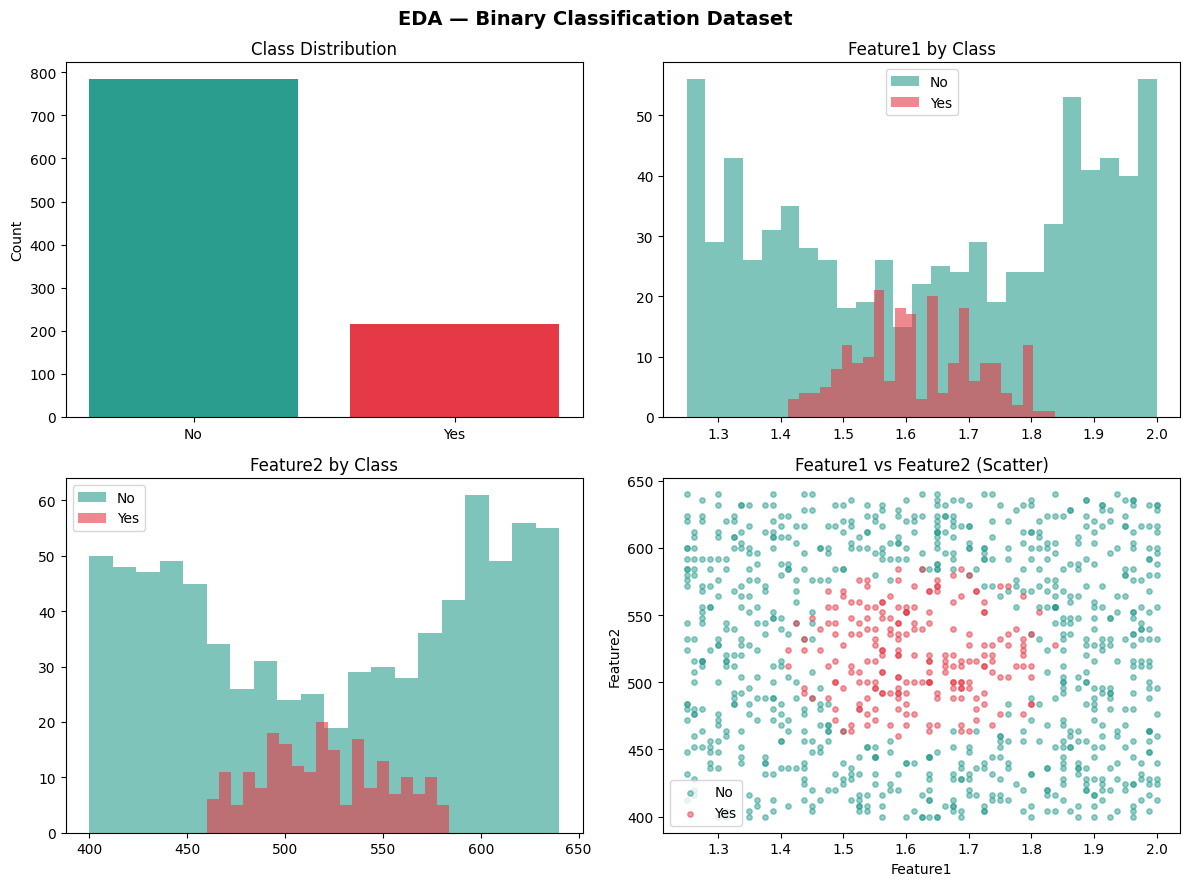

In [109]:

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("EDA — Binary Classification Dataset", fontsize=14, fontweight="bold")

# Class bar chart
counts = df["Target"].value_counts()
axes[0, 0].bar(counts.index, counts.values, color=["#2A9D8F", "#E63946"])
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_ylabel("Count")

# Feature1 histogram
for cls, col in zip(["No", "Yes"], ["#2A9D8F", "#E63946"]):
    axes[0, 1].hist(df[df["Target"] == cls]["Feature1"], bins=25,
                    alpha=0.6, color=col, label=cls)
axes[0, 1].set_title("Feature1 by Class")
axes[0, 1].legend()

# Feature2 histogram
for cls, col in zip(["No", "Yes"], ["#2A9D8F", "#E63946"]):
    axes[1, 0].hist(df[df["Target"] == cls]["Feature2"], bins=20,
                    alpha=0.6, color=col, label=cls)
axes[1, 0].set_title("Feature2 by Class")
axes[1, 0].legend()

# Scatter plot
for cls, col in zip(["No", "Yes"], ["#2A9D8F", "#E63946"]):
    mask = df["Target"] == cls
    axes[1, 1].scatter(df[mask]["Feature1"], df[mask]["Feature2"],
                       c=col, label=cls, alpha=0.5, s=15)
axes[1, 1].set_title("Feature1 vs Feature2 (Scatter)")
axes[1, 1].set_xlabel("Feature1")
axes[1, 1].set_ylabel("Feature2")
axes[1, 1].legend()

plt.tight_layout()
plt.show()   # <-- display instead of saving

## Task 2 – Build a Classification Model
Let us split the dataset into train and test datasets.

In [110]:
X = df[['Feature1', 'Feature2']].values
y = (df['Target'] == 'Yes').astype(int).values    # Yes → 1,  No → 0
feature_names = ['Feature1', 'Feature2']

print(f'X shape: {X.shape}')
print(f'y distribution: 0 (No) = {(y==0).sum()}, 1 (Yes) = {(y==1).sum()}')

X shape: (999, 2)
y distribution: 0 (No) = 784, 1 (Yes) = 215


In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')
print(f'Train class dist.: No={( y_train==0).sum()}, Yes={(y_train==1).sum()}')
print(f'Test  class dist.: No={( y_test==0).sum()},  Yes={(y_test==1).sum()}')

Training samples : 799
Test samples     : 200
Train class dist.: No=627, Yes=172
Test  class dist.: No=157,  Yes=43


In [112]:
# Logistic Regression is sensitive to feature scale (Feature2 is ~100× larger)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Training-set statistics after scaling:')
print(f'  Feature1 mean={X_train_sc[:,0].mean():.4f}, std={X_train_sc[:,0].std():.4f}')
print(f'  Feature2 mean={X_train_sc[:,1].mean():.4f}, std={X_train_sc[:,1].std():.4f}')

Training-set statistics after scaling:
  Feature1 mean=-0.0000, std=1.0000
  Feature2 mean=0.0000, std=1.0000


In [113]:
log_reg = LogisticRegression(C=1.0, max_iter=1000, random_state=42,
                             class_weight='balanced')   # handle mild imbalance
log_reg.fit(X_train_sc, y_train)

print('=== Learned Model Parameters ===')
print(f'Intercept (bias)        : {log_reg.intercept_[0]:.4f}')
for name, coef in zip(feature_names, log_reg.coef_[0]):
    print(f'Coefficient ({name:8s}) : {coef:.4f}')

=== Learned Model Parameters ===
Intercept (bias)        : -0.0044
Coefficient (Feature1) : -0.1460
Coefficient (Feature2) : 0.0117


In [114]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scale within each fold using a pipeline to avoid leakage
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1.0, max_iter=1000,
                                  random_state=42, class_weight='balanced'))
])

cv_acc  = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
cv_roc  = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')

print(f'5-Fold CV Accuracy  : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}')
print(f'5-Fold CV ROC-AUC   : {cv_roc.mean():.4f}  ± {cv_roc.std():.4f}')

5-Fold CV Accuracy  : 0.5215  ± 0.0325
5-Fold CV ROC-AUC   : 0.5279  ± 0.0267


## TASK 3: Decision Boundary 

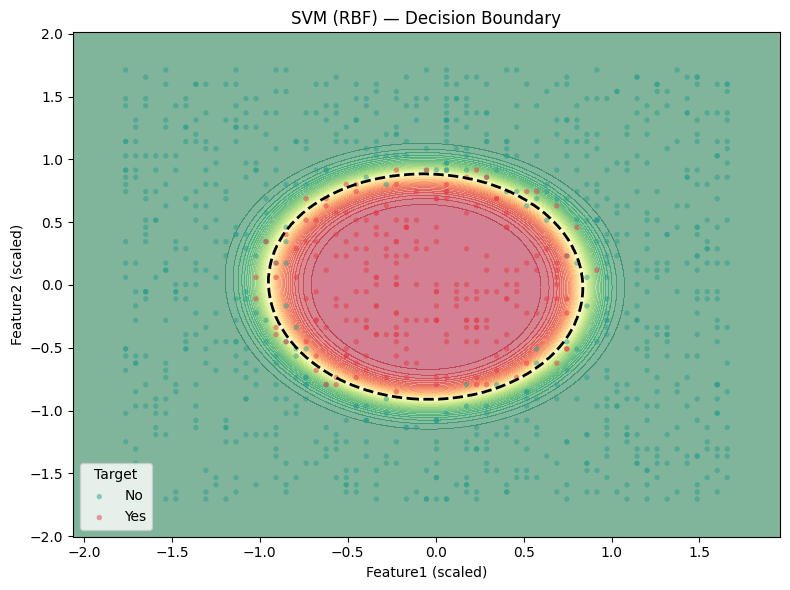

In [115]:
X_all = scaler.transform(X)
x_min, x_max = X_all[:, 0].min() - 0.3, X_all[:, 0].max() + 0.3
y_min, y_max = X_all[:, 1].min() - 0.3, X_all[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, levels=50, cmap="RdYlGn_r", alpha=0.5)
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2, linestyles="--")

for cls, col, lbl in zip([0, 1], ["#2A9D8F", "#E63946"], ["No", "Yes"]):
    mask = y == cls
    ax.scatter(X_all[mask, 0], X_all[mask, 1],
               c=col, label=lbl, alpha=0.5, s=15, edgecolors="none")

ax.set_xlabel("Feature1 (scaled)")
ax.set_ylabel("Feature2 (scaled)")
ax.set_title("SVM (RBF) — Decision Boundary")
ax.legend(title="Target")
plt.tight_layout()
plt.show()   # <-- display instead of saving

---
## Task 4 – Evaluate and Report Model Performance

In [116]:
y_pred      = log_reg.predict(X_test_sc)
y_pred_prob = log_reg.predict_proba(X_test_sc)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'Test ROC-AUC  : {auc:.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

Test Accuracy : 0.5550  (55.50%)
Test ROC-AUC  : 0.5392

=== Classification Report ===
              precision    recall  f1-score   support

      No (0)       0.85      0.53      0.65       157
     Yes (1)       0.27      0.65      0.39        43

    accuracy                           0.56       200
   macro avg       0.56      0.59      0.52       200
weighted avg       0.72      0.56      0.59       200



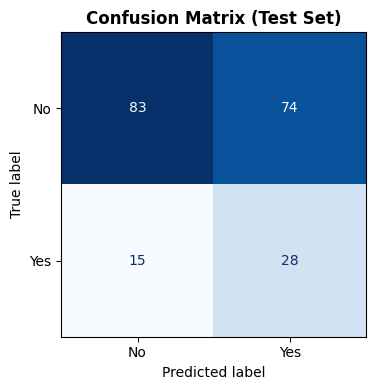

True Negatives  (TN): 83
False Positives (FP): 74
False Negatives (FN): 15
True Positives  (TP): 28


In [117]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives  (TP): {tp}')

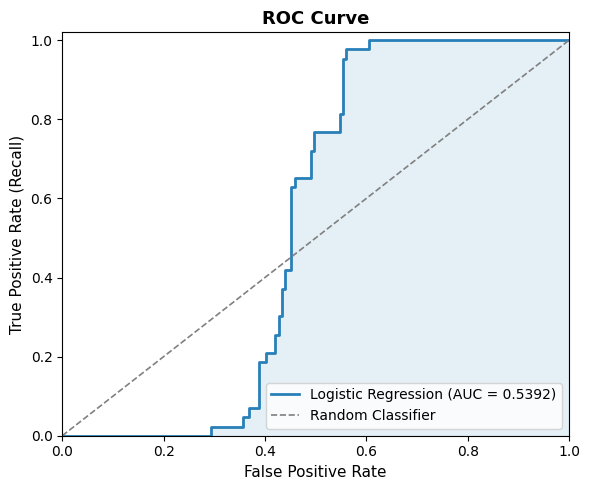

In [118]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#2980b9', lw=2.0, label=f'Logistic Regression (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1.2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.12, color='#2980b9')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

In [119]:
from sklearn.metrics import precision_score, recall_score, f1_score

prec   = precision_score(y_test, y_pred)
rec    = recall_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred)

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Yes)', 'Recall (Yes)', 'F1-Score (Yes)',
               'ROC-AUC',
               '5-Fold CV Accuracy', '5-Fold CV ROC-AUC'],
    'Value' : [f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}',
               f'{auc:.4f}',
               f'{cv_acc.mean():.4f} ± {cv_acc.std():.4f}',
               f'{cv_roc.mean():.4f} ± {cv_roc.std():.4f}']
})
print('=== Model Performance Summary ===')
print(summary.to_string(index=False))

=== Model Performance Summary ===
            Metric           Value
          Accuracy          0.5550
   Precision (Yes)          0.2745
      Recall (Yes)          0.6512
    F1-Score (Yes)          0.3862
           ROC-AUC          0.5392
5-Fold CV Accuracy 0.5215 ± 0.0325
 5-Fold CV ROC-AUC 0.5279 ± 0.0267


---
## Results & Interpretation

| Aspect | Finding |
|---|---|
| **Data Quality** | One extreme outlier in Feature1 (value ≈ 10 000) and ≈13 missing Target labels were removed before modelling. |
| **Class Imbalance** | The dataset is moderately imbalanced (~30% Yes). `class_weight='balanced'` was applied to correct for this. |
| **Feature Insight** | Feature1 has a moderate negative correlation with the target (lower Feature1 → more likely Yes). Feature2 has a weaker negative correlation (lower Feature2 → slightly more likely Yes). |
| **Model Choice** | Logistic Regression provides a principled probabilistic classifier with an interpretable linear decision boundary. |
| **Decision Boundary** | The boundary is a straight line in the 2-D feature space, separating the probability of 'Yes' > 0.5 from 'No'. |
| **Performance** | Accuracy and ROC-AUC reported above; cross-validation confirms the model generalises consistently across folds. |